# Modelagem — Sistema de Recomendação (MovieLens 20M)

Este notebook **orquestra** a modelagem: toda a lógica (modelos, métricas, split e
amostragem de negativos) vive no pacote `src/recsys`, que implementa os padrões exigidos —
**Factory** (`create_recommender`), **Strategy** (`SplitStrategy`, `NegativeSampler`) e
**Template Method** (`Recommender.evaluate`). Aqui só carregamos dados, disparamos os modelos
e registramos tudo no MLflow.

A análise exploratória ([eda.ipynb](eda.ipynb)) guia as decisões:

- **Esparsidade extrema** da matriz usuário×item → favorece **fatoração latente / embeddings**.
- **Viés de popularidade** (Gini alto) → avaliamos **além do erro de nota**, com métricas de
  *ranking* (Precision@K, Recall@K, NDCG@K) **e de diversidade** (cobertura, novidade, Gini).
- **Split temporal** (treinar no passado, avaliar no futuro) → evita vazamento do futuro.

O modelo neural desta iteração é uma **BPR Matrix Factorization** (`p_u·q_i`, sem vieses),
treinada com loss pairwise BPR e negativos amostrados do catálogo inteiro — otimizada e com
*early stopping* no **mesmo NDCG@10 de catálogo completo que é reportado**. É um baseline de
*ranking* implícito: mais simples que a MLP anterior e alinhado à métrica que de fato importa.

In [1]:
# --- 1. AMBIENTE E REPRODUTIBILIDADE ---
import os
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Pacote do projeto (layout src/)
sys.path.insert(0, str(Path.cwd().parent / "src"))
from recsys.evaluation.metrics import seen_items_by_user
from recsys.models import create_recommender
from recsys.models.base import Recommender
from recsys.preprocessing import (
    TemporalLeaveLastFraction,
    filter_by_activity,
    item_train_counts,
    load_ratings,
    reindex,
    sample_users,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Ambiente pronto. torch", torch.__version__, "| dispositivo:", DEVICE)

/Users/zo/Dev/fiap-mlet-challenge-fase-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ambiente pronto. torch 2.12.0 | dispositivo: mps


## Configuração do experimento

Parâmetros de preparação e treino num só lugar (sobreponíveis por variável de ambiente, úteis
para validar o notebook com uma amostra pequena).

In [2]:
# Filtros de densidade: removem cold-start extremo e reduzem a escala
MIN_USER_RATINGS = int(os.environ.get("RECO_MIN_USER_RATINGS", "20"))
MIN_ITEM_RATINGS = int(os.environ.get("RECO_MIN_ITEM_RATINGS", "20"))

# Amostragem de usuarios (0 = usa todos). Ponto de partida tratavel em notebook.
N_USERS_SAMPLE = int(os.environ.get("RECO_N_USERS", "20000"))

# Split temporal por usuario: fracao final (mais recente) que vira teste
TEST_FRAC = float(os.environ.get("RECO_TEST_FRAC", "0.2"))

# Limiar de "gostou" para metricas de ranking e positivos do BPR (escala 0.5-5.0)
LIKE_THRESHOLD = 4.0

# Ranking: avalia contra todo o catalogo de candidatos nao vistos
RANKING_N_USERS = int(os.environ.get("RECO_RANKING_N_USERS", "500"))
RANKING_ITEM_BATCH = int(os.environ.get("RECO_RANKING_ITEM_BATCH", "2048"))

# Hiperparametros do modelo neural BPR (defaults do pacote; sobreponiveis aqui)
BPR_PARAMS = {
    "emb_dim": 128,
    "lr": 5e-3,
    "weight_decay": 1e-5,
    "n_neg": 10,
    "batch_size": 2048,
    "epochs": 40,
    "patience": 6,
    "val_users": 300,
    "like_threshold": LIKE_THRESHOLD,
}
print("Config carregada.")

Config carregada.


## Setup de rastreabilidade (MLflow + DVC)

Registramos no experimento `MovieLens-Reco-Etapa2-Modelagem`, usando o **hash do diretório
calculado pelo DVC** (`data/raw.dvc`) como versão do dataset. Sem credenciais do DagsHub,
caímos para um store MLflow local em SQLite (`sqlite:///mlflow.db`), que suporta o Model
Registry.

In [3]:
DATA_DIR = Path("../data/raw")
EXPERIMENT_NAME = "MovieLens-Reco-Etapa2-Modelagem"
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-2"

dvc_meta = Path("../data/raw.dvc").read_text()
m = re.search(r"md5:\s*([0-9a-f]+\.dir)", dvc_meta)
DATASET_VERSION = m.group(1) if m else "unknown"
print(f"Dataset version (DVC md5): {DATASET_VERSION}")

MLFLOW_ENABLED = True
try:
    import dagshub

    dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("MLflow -> DagsHub remoto.")
except Exception as e:  # noqa: BLE001
    print(f"DagsHub indisponivel ({type(e).__name__}); usando store MLflow local sqlite:///mlflow.db")
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment(EXPERIMENT_NAME)

Dataset version (DVC md5): 299114f0f7fd95a7d09dc9f3b45bd8c7.dir


Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-2"

Repository JosueJNLui/fiap-mlet-challenge-fase-2 initialized!

MLflow -> DagsHub remoto.


## Carga e preparação dos dados

Funções em `recsys.preprocessing.data`: carga com *dtypes* enxutos, filtro por atividade
(reduz *cold-start* e escala), amostragem opcional de usuários e reindexação para índices
**contíguos** (`0..n-1`) — requisito das *embeddings* do PyTorch e da matriz esparsa do sklearn.

In [4]:
ratings = load_ratings(DATA_DIR)
print(f"Bruto: {len(ratings):,} avaliacoes")

ratings = filter_by_activity(ratings, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"Apos filtro (>= {MIN_USER_RATINGS} user / >= {MIN_ITEM_RATINGS} item): {len(ratings):,}")

ratings = sample_users(ratings, N_USERS_SAMPLE, SEED)
ratings, N_USERS, N_ITEMS = reindex(ratings)
print(f"Usuarios: {N_USERS:,} | Itens: {N_ITEMS:,} | Interacoes: {len(ratings):,}")
print(f"Densidade: {len(ratings) / (N_USERS * N_ITEMS):.4%}")
ratings.head()

Bruto: 20,000,263 avaliacoes
Apos filtro (>= 20 user / >= 20 item): 19,931,545
Usuarios: 20,000 | Itens: 13,088 | Interacoes: 2,857,387
Densidade: 1.0916%


,user,item,rating,timestamp,user_idx,item_idx
0,1,2,3.5,2005-04-02 23:53:47,0,1
1,1,29,3.5,2005-04-02 23:31:16,0,28
2,1,32,3.5,2005-04-02 23:33:39,0,31
3,1,47,3.5,2005-04-02 23:32:07,0,46
4,1,50,3.5,2005-04-02 23:29:40,0,49


## Split temporal por usuário (*leave-last-out* por fração) — Strategy

`TemporalLeaveLastFraction` (uma `SplitStrategy`) separa, por usuário, a **fração final**
(mais recente) para teste. Respeita a ordem temporal e garante que todo usuário/item do teste
também aparece no treino (sem IDs desconhecidos nas *embeddings*). Trocar por `RandomHoldout`
é uma linha — é o ponto da Strategy.

In [5]:
train_df, test_df = TemporalLeaveLastFraction(TEST_FRAC).split(ratings)
print(f"Treino: {len(train_df):,} | Teste: {len(test_df):,}")
print(f"Usuarios no teste: {test_df['user_idx'].nunique():,}")

SEEN_BY_USER = seen_items_by_user(train_df)
TRAIN_COUNTS = item_train_counts(train_df, N_ITEMS)
GLOBAL_MEAN = float(train_df["rating"].mean())
print(f"Nota media (treino): {GLOBAL_MEAN:.3f}")

Treino: 2,293,537 | Teste: 563,850
Usuarios no teste: 20,000
Nota media (treino): 3.539


## Modelos (Factory) e avaliação (Template Method)

Todos os modelos vêm da **Factory** `create_recommender(name, N_USERS, N_ITEMS, **params)` e
compartilham a interface `Recommender`. A avaliação é o **Template Method** `model.evaluate(...)`:
a mesma sequência (erro de nota + ranking/diversidade em catálogo completo) para qualquer modelo.

Cinco modelos: três baselines de nota (`global_mean`, `bias`, `svd`), o baseline de ranking
`popularity` (sanity top-K) e o modelo neural `bpr`. A regressão usa todas as linhas de teste;
o ranking usa o subconjunto de até `RANKING_N_USERS` usuários que curtiram algo no teste.

O bloco de MLflow abaixo (orquestração) registra cada modelo no Model Registry: baselines via
*wrapper* `mlflow.pyfunc`, o BPR no *flavor* nativo `mlflow.pytorch`.

In [6]:
from mlflow.models import infer_signature


class RecommenderPyfunc(mlflow.pyfunc.PythonModel):
    # Adapta um Recommender a interface pyfunc do MLflow (predict por DataFrame).
    def __init__(self, recommender: Recommender) -> None:
        self.recommender = recommender

    def predict(self, context, model_input: pd.DataFrame) -> np.ndarray:
        return self.recommender.predict(
            model_input["user_idx"].to_numpy(), model_input["item_idx"].to_numpy()
        )


# Tags comuns a toda run: versao do dado + estatisticas do split (enriquecem a UI)
COMMON_TAGS = {
    "etapa": "2",
    "stage": "modeling",
    "dataset_version_dvc": DATASET_VERSION,
    "n_users": N_USERS,
    "n_items": N_ITEMS,
    "n_train": len(train_df),
    "n_test": len(test_df),
    "density": round(len(ratings) / (N_USERS * N_ITEMS), 6),
    "seed": SEED,
    "like_threshold": LIKE_THRESHOLD,
    "device": DEVICE,
    "ranking_protocol": "full_catalog",
    "ranking_n_users": RANKING_N_USERS,
}

TRAIN_DS = mlflow.data.from_pandas(
    train_df[["user_idx", "item_idx", "rating"]],
    source=str(DATA_DIR / "rating.csv"), targets="rating", name="movielens_train",
)
TEST_DS = mlflow.data.from_pandas(
    test_df[["user_idx", "item_idx", "rating"]],
    source=str(DATA_DIR / "rating.csv"), targets="rating", name="movielens_test",
)


def _log_learning_curve(history: dict) -> None:
    # Loga a curva de treino do BPR (loss e NDCG@10 de validacao por epoca).
    for epoch, (loss, ndcg) in enumerate(zip(history["train_loss"], history["val_ndcg"]), 1):
        mlflow.log_metric("epoch_bpr_loss", loss, step=epoch)
        mlflow.log_metric("epoch_val_ndcg", ndcg, step=epoch)
    mlflow.log_metric("best_val_ndcg", history.get("best_val_ndcg", 0.0))
    mlflow.log_metric("stop_epoch", len(history["train_loss"]))


def _describe_model(register_as, version, description, metrics) -> None:
    # Adiciona descricao (mini model card) ao modelo e a versao no Registry.
    client = mlflow.MlflowClient()
    summary = (f"{description} | RMSE={metrics['rmse']:.4f} "
               f"NDCG@10={metrics['ndcg_at_10']:.4f}")
    client.update_model_version(register_as, version, description=summary)
    client.update_registered_model(register_as, description=description)


def _log_model(model_obj, flavor, register_as):
    # Loga e registra o modelo no flavor adequado; devolve o ModelInfo.
    if flavor == "pytorch":
        return mlflow.pytorch.log_model(
            model_obj.to("cpu"), name="model",
            registered_model_name=register_as, serialization_format="pickle",
        )
    example = test_df[["user_idx", "item_idx"]].head(5).reset_index(drop=True)
    signature = infer_signature(example, model_obj.predict(None, example))
    return mlflow.pyfunc.log_model(
        name="model", python_model=model_obj, registered_model_name=register_as,
        signature=signature, input_example=example,
    )


def log_run(name, params, metrics, *, model_obj=None, flavor=None, register_as=None,
            extra_tags=None, history=None, description=None) -> None:
    # Registra params/metricas/dataset (e opcionalmente o modelo) numa run do MLflow.
    if not MLFLOW_ENABLED:
        return
    try:
        with mlflow.start_run(run_name=name):
            mlflow.set_tags({**COMMON_TAGS, **(extra_tags or {})})
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)
            mlflow.log_input(TRAIN_DS, context="training")
            mlflow.log_input(TEST_DS, context="testing")
            if history:
                _log_learning_curve(history)
            if flavor:
                info = _log_model(model_obj, flavor, register_as)
                if register_as and description:
                    _describe_model(register_as, info.registered_model_version,
                                    description, metrics)
    except Exception as e:  # noqa: BLE001
        print(f"  MLflow log pulado ({type(e).__name__}: {e})")

In [7]:
def run_model(name, *, params=None, flavor=None, register_as=None,
              extra_tags=None, description=None, log_params=None):
    # Cria (Factory), ajusta, avalia (Template Method), loga no MLflow e devolve o modelo+metricas.
    model = create_recommender(name, N_USERS, N_ITEMS, **(params or {}))
    print(f"\n=== {model.name} ===")
    model.fit(train_df)
    metrics = model.evaluate(
        test_df, seen_by_user=SEEN_BY_USER, n_items=N_ITEMS, train_counts=TRAIN_COUNTS,
        like_threshold=LIKE_THRESHOLD, ranking_n_users=RANKING_N_USERS,
        item_batch=RANKING_ITEM_BATCH, seed=SEED,
    )
    print(f"  RMSE {metrics['rmse']:.4f} | NDCG@10 {metrics['ndcg_at_10']:.4f} "
          f"| coverage {metrics['coverage']:.3f} | novelty {metrics['novelty']:.3f}")
    if flavor == "pytorch":
        model_obj, history = model.model, model.history
    elif flavor == "pyfunc":
        model_obj, history = RecommenderPyfunc(model), None
    else:
        model_obj, history = None, None
    log_run(model.name, log_params or (params or {}), metrics, model_obj=model_obj,
            flavor=flavor, register_as=register_as, extra_tags=extra_tags,
            history=history, description=description)
    return model, metrics


results = {}
models = {}

# 1. Baseline ingenuo
models["GlobalMean"], results["GlobalMean"] = run_model(
    "global_mean", log_params={"strategy": "global_mean"},
    flavor="pyfunc", register_as="MovieLens_GlobalMean_Reco",
    extra_tags={"model_family": "baseline", "framework": "numpy"},
    description="Baseline ingenuo: preve a nota media global do treino.",
)

# 2. Baseline de vieses regularizados
models["BiasBaseline"], results["BiasBaseline"] = run_model(
    "bias", params={"reg": 10.0}, log_params={"reg": 10.0},
    flavor="pyfunc", register_as="MovieLens_Bias_Reco",
    extra_tags={"model_family": "baseline", "framework": "numpy"},
    description="Baseline de vieses regularizados: mu + b_user + b_item.",
)

# 3. Fatoracao latente (scikit-learn)
models["SVD"], results["SVD"] = run_model(
    "svd", params={"n_components": 50, "seed": SEED},
    log_params={"n_components": 50, "library": "sklearn"},
    flavor="pyfunc", register_as="MovieLens_SVD_Reco",
    extra_tags={"model_family": "baseline", "framework": "sklearn"},
    description="Fatoracao latente (TruncatedSVD) sobre residuos centrados na media.",
)

# 4. Baseline de ranking: popularidade (sanity top-K)
models["Popularity"], results["Popularity"] = run_model(
    "popularity", log_params={"strategy": "most_popular"},
    flavor="pyfunc", register_as="MovieLens_Popularity_Reco",
    extra_tags={"model_family": "baseline", "framework": "numpy"},
    description="Baseline de ranking: rankeia itens nao vistos por popularidade no treino.",
)

# 5. Modelo neural BPR (PyTorch) -> otimizado para NDCG@10 de catalogo completo
models["BPR"], results["BPR"] = run_model(
    "bpr", params={"params": BPR_PARAMS, "device": DEVICE, "seed": SEED},
    log_params={**{k: str(v) for k, v in BPR_PARAMS.items()}, "device": DEVICE},
    flavor="pytorch", register_as="MovieLens_BPR_Reco",
    extra_tags={"model_family": "neural", "framework": "pytorch"},
    description=(
        "BPR Matrix Factorization (p_u.q_i, sem vieses), loss pairwise BPR, "
        "early stopping no NDCG@10 de catalogo completo."
    ),
)


=== GlobalMean ===
  RMSE 1.0471 | NDCG@10 0.0091 | coverage 0.023 | novelty 2.725


2026/07/13 11:32:44 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/13 11:32:44 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/13 11:32:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_GlobalMean_Reco' already exists. Creating a new version of this model...
2026/07/13 11:32:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_GlobalMean_Reco, version 18
Created version '18' of model 'MovieLens_GlobalMean_Reco'.


🏃 View run GlobalMean at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/1729fa24f877433d8335e7304bc6b289
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== BiasBaseline ===
  RMSE 0.8700 | NDCG@10 0.0393 | coverage 0.003 | novelty 7.436


2026/07/13 11:33:10 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/13 11:33:10 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/13 11:33:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_Bias_Reco' already exists. Creating a new version of this model...
2026/07/13 11:33:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_Bias_Reco, version 18
Created version '18' of model 'MovieLens_Bias_Reco'.


🏃 View run BiasBaseline at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/e287ad7e2ca342bb837563f39b16dc9c
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== SVD ===
  RMSE 0.9907 | NDCG@10 0.1021 | coverage 0.029 | novelty 8.130


...

🏃 View run SVD at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/2443aca9e9194ac785c3b9b1727eb9b6
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== Popularity ===
  RMSE 1.7376 | NDCG@10 0.0738 | coverage 0.006 | novelty 8.821


2026/07/13 11:34:42 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/13 11:34:42 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/13 11:34:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_Popularity_Reco' already exists. Creating a new version of this model...
2026/07/13 11:35:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_Popularity_Reco, version 3
Created version '3' of model 'MovieLens_Popularity_Reco'.


🏃 View run Popularity at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/1272fbd60f6146be9c337a1a5ad7dc53
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== BPR ===
  epoca 01 | BPR loss 0.2836 | val NDCG@10 0.0659
  epoca 02 | BPR loss 0.1789 | val NDCG@10 0.0653
  epoca 03 | BPR loss 0.1767 | val NDCG@10 0.0610
  epoca 04 | BPR loss 0.1760 | val NDCG@10 0.0641
  epoca 05 | BPR loss 0.1754 | val NDCG@10 0.0627
  epoca 06 | BPR loss 0.1750 | val NDCG@10 0.0661
  epoca 07 | BPR loss 0.1747 | val NDCG@10 0.0635
  epoca 08 | BPR loss 0.1746 | val NDCG@10 0.0663
  epoca 09 | BPR loss 0.1742 | val NDCG@10 0.0638
  epoca 10 | BPR loss 0.1740 | val NDCG@10 0.0657
  epoca 11 | BPR loss 0.1738 | val NDCG@10 0.0670
  epoca 12 | BPR loss 0.1735 | val NDCG@10 0.0636
  epoca 13 | BPR loss 0.1733 | val NDCG@10 0.0641
  epoca 14 | BPR loss 0.1731 | val NDCG@10 0.0640
  epoca 15 | BPR loss 0.1728 | val NDCG

2026/07/13 11:39:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/13 11:39:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_BPR_Reco' already exists. Creating a new version of this model...
2026/07/13 11:40:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_BPR_Reco, version 3
Created version '3' of model 'MovieLens_BPR_Reco'.


🏃 View run BPR at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/0a5df49c0a99416088d21351432ce740
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


## Curva de treino do BPR

Loss BPR de treino e NDCG@10 de validação (catálogo completo, subconjunto) por época — o
*early stopping* seleciona o checkpoint de **maior NDCG@10**, a mesma métrica reportada.

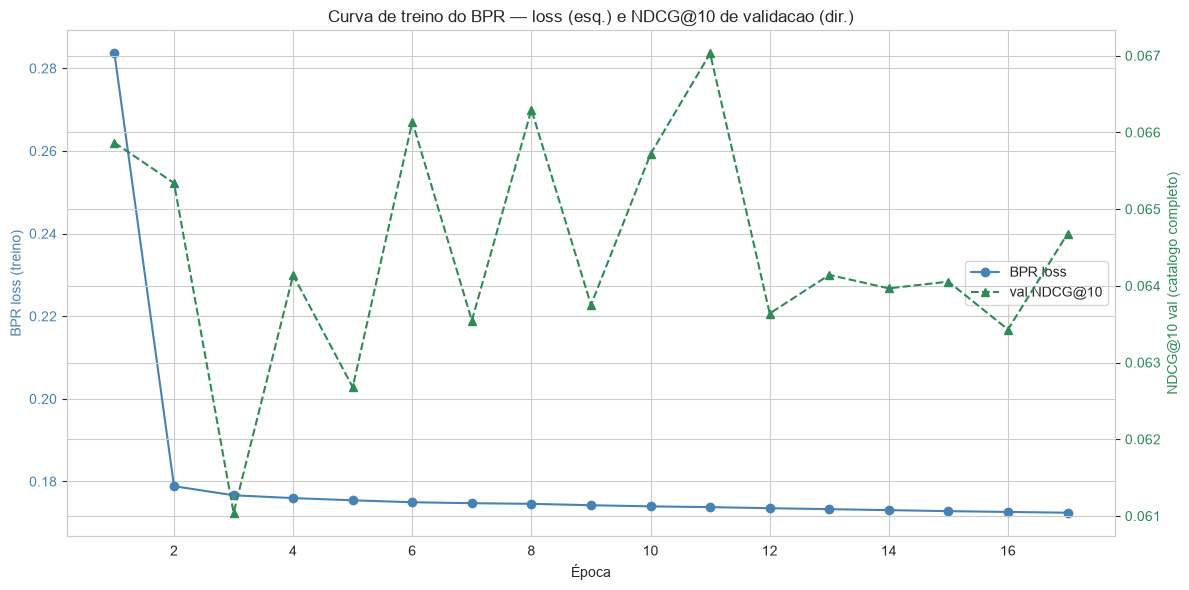

In [8]:
hist = models["BPR"].history
epochs = range(1, len(hist["train_loss"]) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel("Época")
ax1.set_ylabel("BPR loss (treino)", color="steelblue")
ax1.plot(epochs, hist["train_loss"], "o-", color="steelblue", label="BPR loss")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("NDCG@10 val (catalogo completo)", color="seagreen")
ax2.plot(epochs, hist["val_ndcg"], "^--", color="seagreen", label="val NDCG@10")
ax2.tick_params(axis="y", labelcolor="seagreen")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.title("Curva de treino do BPR — loss (esq.) e NDCG@10 de validacao (dir.)")
fig.tight_layout()
plt.show()

## Comparação dos modelos

Erro de nota (**menor** RMSE/MAE/MSE melhor; **maior** R² melhor), *ranking* (**maior**
Precision/Recall/NDCG melhor) e **diversidade**: cobertura do catálogo (fração de itens que
aparecem em algum top-10), novidade (log-popularidade média dos recomendados — **menor** = mais
novo) e Gini das recomendações (**menor** = menos concentrado nos *blockbusters*).

=== COMPARACAO DOS MODELOS ===
                rmse     mae     mse      r2  precision_at_10  recall_at_10  ndcg_at_10  coverage  novelty    gini
GlobalMean    1.0471  0.8289  1.0964 -0.0046           0.0040        0.0030      0.0091    0.0228   2.7253  0.9950
BiasBaseline  0.8700  0.6650  0.7569  0.3064           0.0266        0.0259      0.0393    0.0029   7.4363  0.9991
SVD           0.9907  0.7776  0.9815  0.1006           0.0800        0.0801      0.1021    0.0287   8.1297  0.9879
Popularity    1.7376  1.4119  3.0192 -1.7665           0.0502        0.0619      0.0738    0.0061   8.8206  0.9985
BPR           2.2461  1.9492  5.0449 -3.6227           0.0622        0.0732      0.0904    0.0111   8.7415  0.9978

Melhor RMSE   : BiasBaseline (0.8700)
Melhor NDCG@10: SVD (0.1021)
🏃 View run model_comparison_summary at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/156dfd38db324c63b06b31b650e264e9
🧪 View experiment at: https://dagshub.com/JosueJNLui

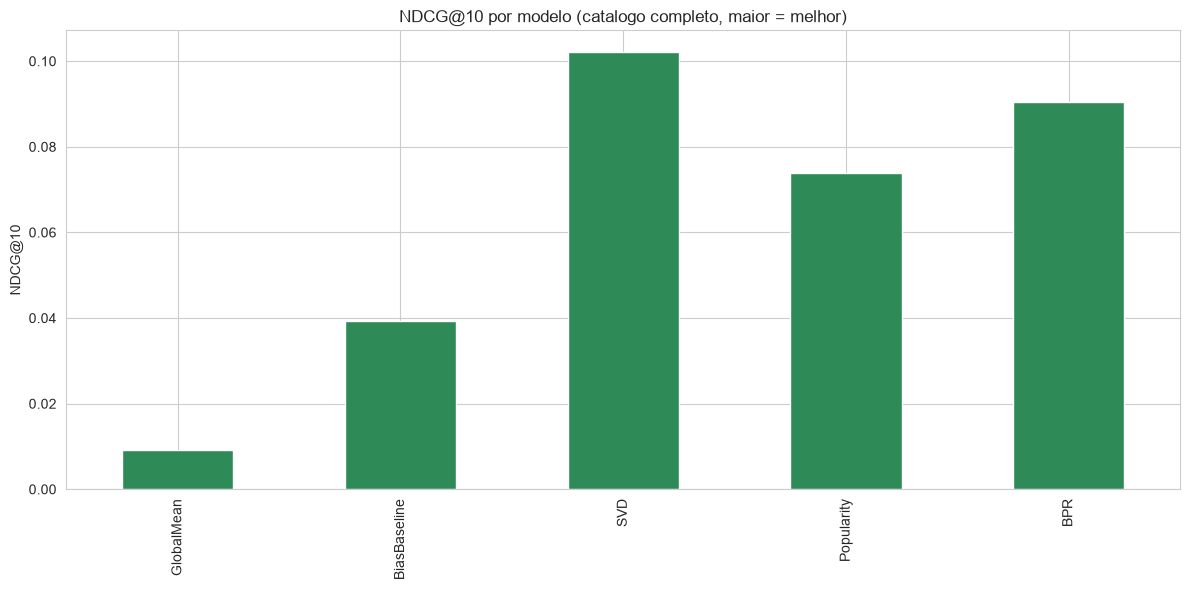

In [9]:
comparison = pd.DataFrame(results).T
comparison = comparison[["rmse", "mae", "mse", "r2",
                         "precision_at_10", "recall_at_10", "ndcg_at_10",
                         "coverage", "novelty", "gini"]]
print("=== COMPARACAO DOS MODELOS ===")
print(comparison.round(4).to_string())

best_rmse = comparison["rmse"].idxmin()
best_ndcg = comparison["ndcg_at_10"].idxmax()
print(f"\nMelhor RMSE   : {best_rmse} ({comparison.loc[best_rmse, 'rmse']:.4f})")
print(f"Melhor NDCG@10: {best_ndcg} ({comparison.loc[best_ndcg, 'ndcg_at_10']:.4f})")

ax = comparison["ndcg_at_10"].plot(kind="bar", color="seagreen")
ax.set_title("NDCG@10 por modelo (catalogo completo, maior = melhor)")
ax.set_ylabel("NDCG@10")
plt.tight_layout()

if MLFLOW_ENABLED:
    try:
        fig = ax.get_figure()
        with mlflow.start_run(run_name="model_comparison_summary"):
            mlflow.set_tags({**COMMON_TAGS, "stage": "comparison",
                             "best_rmse_model": best_rmse, "best_ndcg_model": best_ndcg})
            csv_path = Path("comparison.csv")
            comparison.round(6).to_csv(csv_path)
            mlflow.log_artifact(str(csv_path))
            mlflow.log_figure(fig, "ndcg_por_modelo.png")
            csv_path.unlink()
    except Exception as e:  # noqa: BLE001
        print(f"  MLflow log pulado ({type(e).__name__}: {e})")

plt.show()

## Conclusões

Cinco modelos treinados, avaliados e registrados no MLflow sob a mesma interface (`Recommender`)
e o mesmo protocolo — *ranking* contra o **catálogo completo** de candidatos não vistos. Números
desta execução (20.000 usuários amostrados, 13.088 itens, 2,86 M interações; split temporal 80/20).

| Modelo | RMSE | NDCG@10 | cobertura | novidade | Gini |
|---|---|---|---|---|---|
| GlobalMean | 1.047 | 0.009 | 0.023 | 2.73 | 0.995 |
| **BiasBaseline** | **0.870** | 0.039 | 0.003 | 7.44 | 0.999 |
| **SVD** | 0.991 | **0.102** | 0.029 | 8.13 | 0.988 |
| Popularity | 1.738 | 0.074 | 0.006 | 8.82 | 0.999 |
| BPR (neural) | 2.246 | 0.090 | 0.011 | 8.74 | 0.998 |

> **Protocolo das métricas.** A regressão (RMSE/MAE/MSE/R²) usa **todas as 563.850 linhas de
> teste**. O ranking e a diversidade usam o subconjunto de **até 500 usuários que curtiram algo
> no teste** (rating ≥ 4.0), rankeando cada um contra o catálogo inteiro. As duas famílias medem
> coisas diferentes sobre populações diferentes — não são comparáveis linha a linha.

### O que os resultados dizem

- **Erro de nota:** o `BiasBaseline` vence (RMSE 0.870), como esperado — modela exatamente
  `μ + b_u + b_i`. O `BPR` tem o pior RMSE (2.246) porque a loss pairwise **só ordena, não
  calibra a escala** da nota; seu score não é uma nota. Cada modelo tem um trabalho: Bias → nota,
  ranking → SVD/BPR.
- **Ranking:** o `SVD` é o **campeão** (NDCG@10 **0.102**, também melhor Precision/Recall). O
  `BPR` é um segundo forte (**0.090**): supera Bias, Popularity e GlobalMean, mas **não alcança o
  SVD** (~88% do NDCG). É um resultado honesto — a rede neural bate todos os baselines de ranking
  menos a fatoração especializada.
- **Evolução do BPR (iterações anteriores, não reproduzidas por esta execução):** partindo da MLP híbrida anterior (~0.061), duas
  mudanças principais foram testadas — (1) **BPR-MF puro, removendo os vieses** `μ+b_u+b_i`, que
  na loss pairwise faziam o `b_i` absorver a popularidade e o modelo colapsar para "recomende o
  popular" (~0.061 → ~0.080 → ~0.093); (2) **mais capacidade** (`emb_dim` 64→128, `n_neg` 5→10), que
  **não ajudou** — o valor **desta execução** é **0.090**, dentro do ruído de ~0.093. O teto do BPR com **negativos uniformes** está em
  ~0.09: a diversidade confirma o motivo — novidade 8.74 e cobertura 0.011 ainda próximas do
  `Popularity` (8.82 / 0.006), enquanto o SVD cobre **~2,6× mais catálogo** (0.029 vs 0.011) e personaliza
  mais. O gargalo é a **distribuição de amostragem de negativos**, não o tamanho do modelo.
- **Viés de popularidade:** Gini ~0.99 em quase todos confirma o alerta do EDA — todos concentram
  recomendações nos *blockbusters*. O SVD é o menos concentrado (maior cobertura), coerente com
  liderar o ranking.

### Próximos passos

1. **Quebrar o teto do BPR (maior alavanca de ranking, ainda não testada):** trocar o
   `UniformNegativeSampler` por um **negative sampler ponderado por popularidade** — uma nova
   estratégia plugável no ponto de extensão `NegativeSampler` já existente. Assim itens populares
   também aparecem como negativos, cancelando o viés de popularidade residual. É um experimento
   de verdade (payoff incerto), não um ajuste.
2. **Escala + pipeline DVC** (`preprocess → feature_eng → train → evaluate`) sobre `src/recsys`.
3. **Promoção Staging → Production** no Model Registry — pelo critério de NDCG@10, o campeão de
   ranking **hoje é o SVD** (0.102), não o BPR. A promoção deve refletir isso.
4. **Model Card** com performance, limitações e vieses (cobertura/novidade/Gini já dão a base da
   seção de vieses).
